In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("7817_1.csv")

Saving 7817_1.csv to 7817_1.csv


In [ ]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

EDA


In [ ]:
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [ ]:
df.isnull().sum()

,0
id,0
asins,0
brand,0
categories,0
colors,823
dateAdded,0
dateUpdated,0
dimension,1032
ean,699
keys,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns:", num_cols)

Numerical columns: ['ean', 'reviews.numHelpful', 'reviews.rating', 'reviews.userCity', 'reviews.userProvince', 'sizes', 'upc']


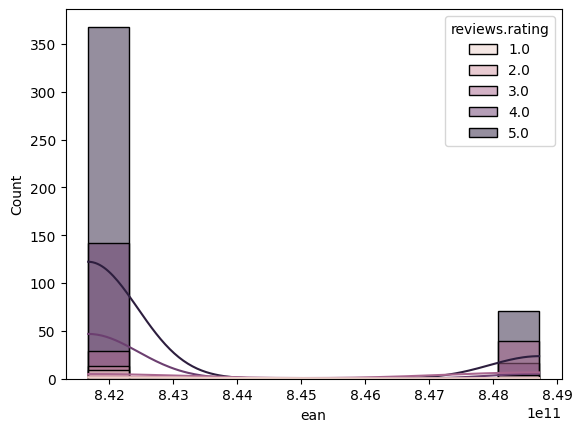

In [ ]:
sns.histplot(data=df, x="ean",hue="reviews.rating", kde=True)

plt.show()

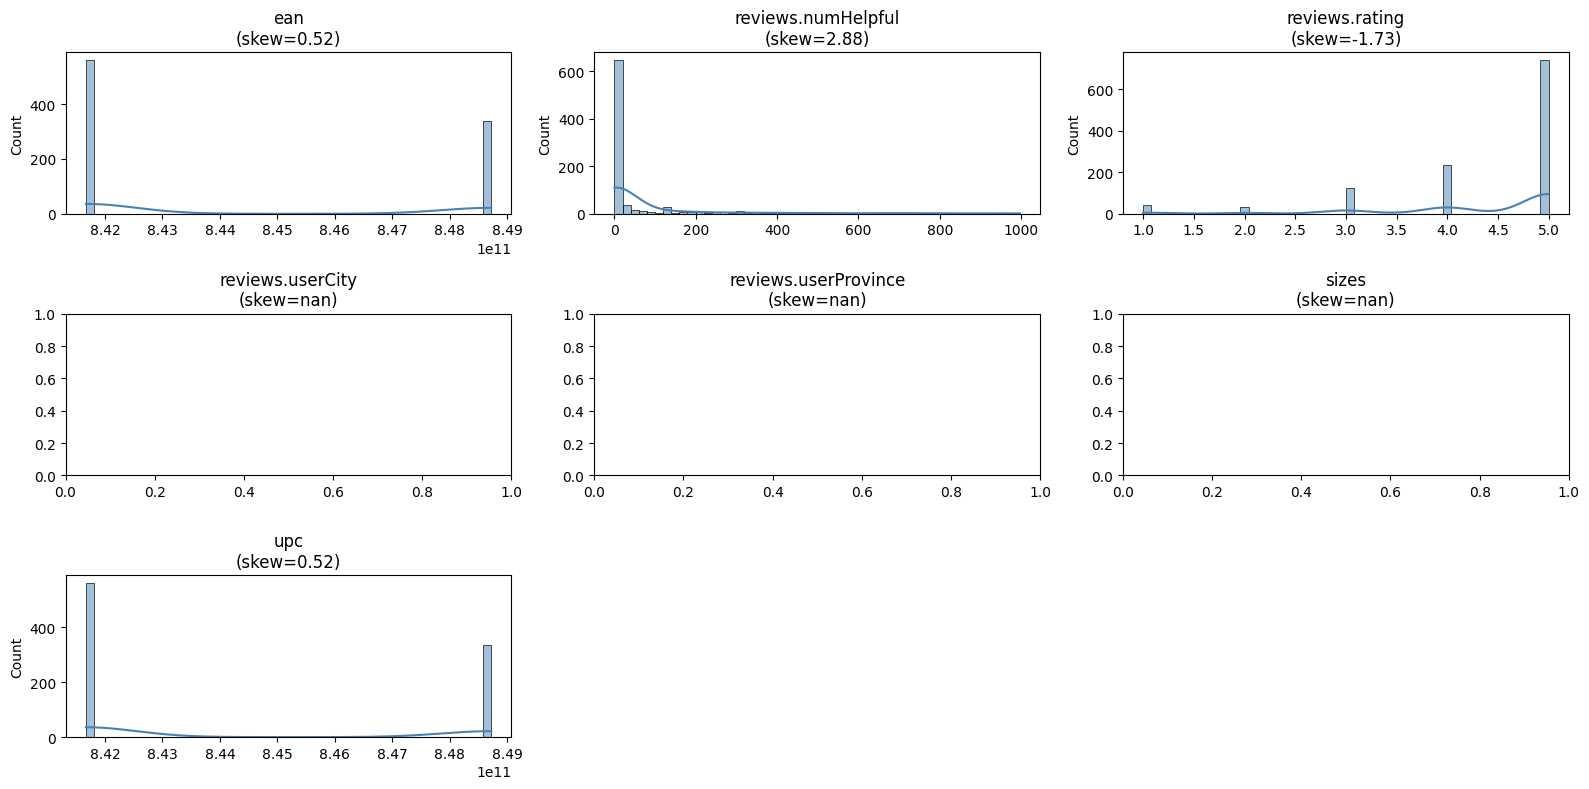

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    sns.histplot(data, bins=50, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}\n(skew={data.skew():.2f})')
    axes[i].set_xlabel('')

# Hide the last empty subplot
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
reviews.userProvince,100.000000
sizes,100.000000
reviews.userCity,100.000000
reviews.doRecommend,66.249217
dimension,64.621165
weight,57.044458
colors,51.534126
upc,43.769568
ean,43.769568
reviews.numHelpful,43.644333


In [ ]:
df = df.drop(columns=["reviews.userProvince", "sizes", "reviews.userCity"])

In [ ]:
df.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'upc', 'weight'],
      dtype='object')

In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
reviews.doRecommend,66.249217
dimension,64.621165
weight,57.044458
colors,51.534126
ean,43.769568
upc,43.769568
reviews.numHelpful,43.644333
manufacturerNumber,43.519098
manufacturer,39.574202
reviews.rating,26.299311


In [ ]:
num_cols.remove("reviews.userProvince")
num_cols.remove("sizes")
num_cols.remove("reviews.userCity")

In [ ]:
cat_cols = df.drop(columns=num_cols).columns.tolist()
print(cat_cols)

['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'weight']


In [ ]:
df.head()


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.date,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,2015-08-08T00:00:00.000Z,NaN,139.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",Cristina M,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,2015-09-01T00:00:00.000Z,NaN,126.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,Ricky,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,2015-07-20T00:00:00.000Z,NaN,69.0,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,Tedd Gardiner,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,2017-06-16T00:00:00.000Z,NaN,2.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,Dougal,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,2016-08-11T00:00:00.000Z,NaN,17.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,Miljan David Tanic,NaN,205 grams


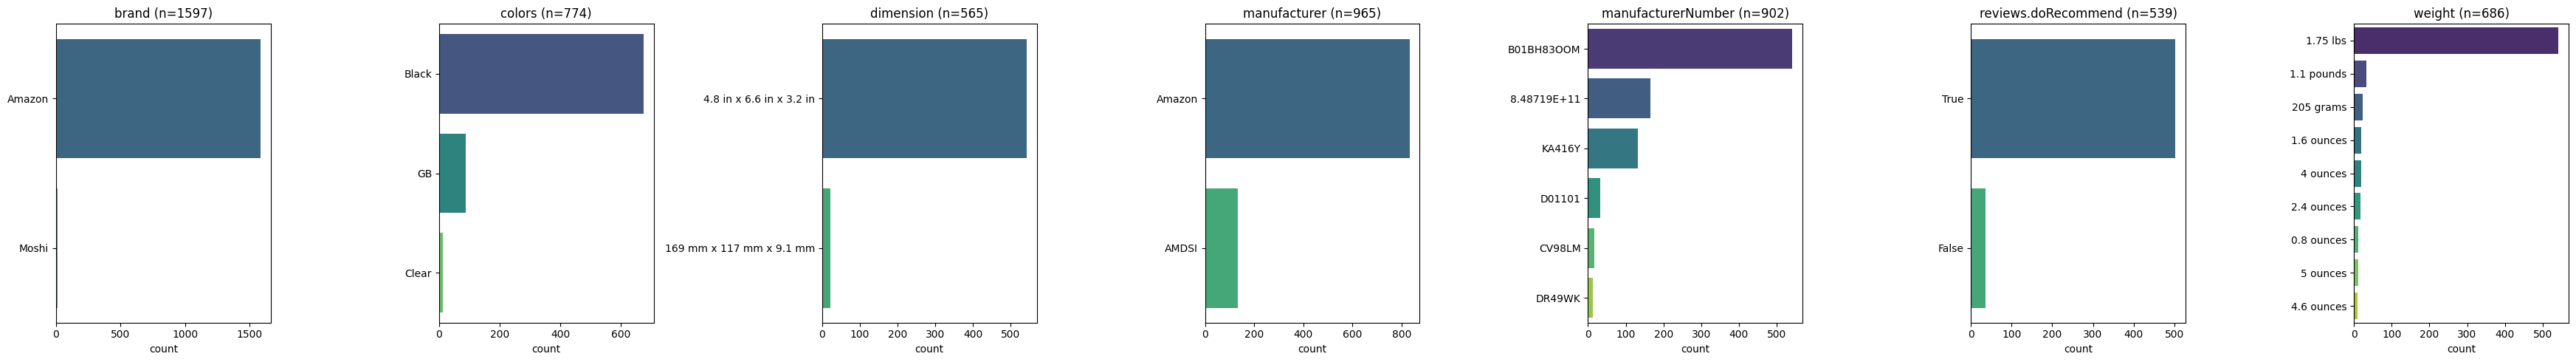

In [ ]:
plot_cols = [c for c in cat_cols if c in df.columns and df[c].nunique() <= 10]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 5))
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, palette='viridis')
    ax.set_title(f'{col} (n={df[col].notna().sum()})')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
df["colors"].value_counts(normalize=True) * 100

,proportion
colors,
Black,87.209302
GB,11.240310
Clear,1.550388


In [ ]:
print(num_cols)

['ean', 'reviews.numHelpful', 'reviews.rating', 'upc']


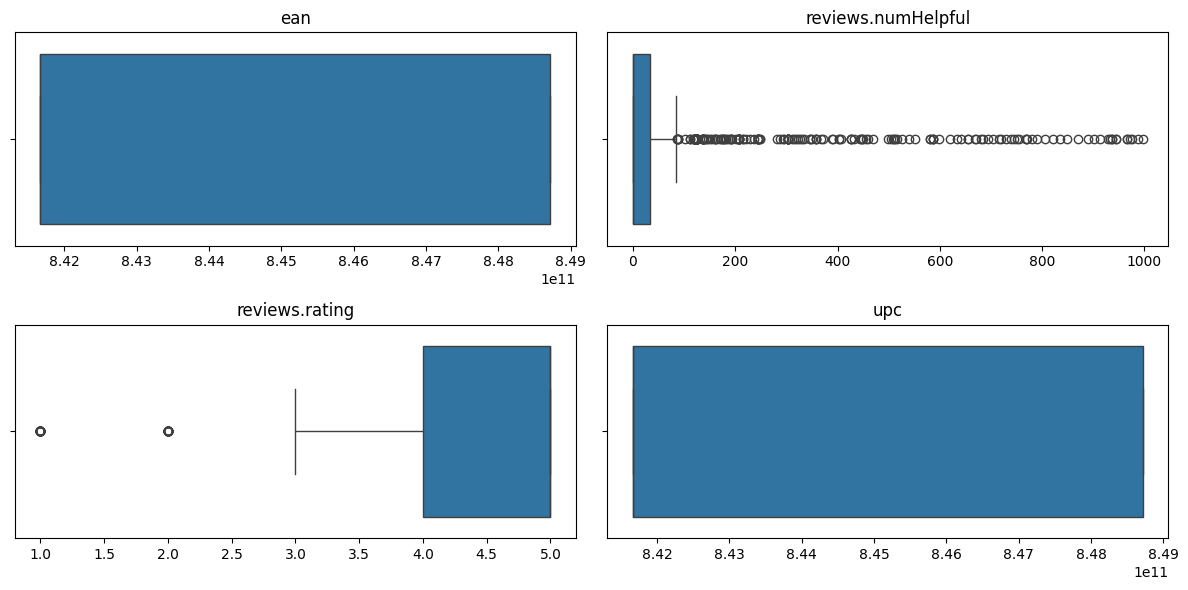

In [ ]:
fig, axes=plt.subplots(2, 2, figsize=(12, 6))
axes=axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')


plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,ean,reviews.numHelpful,reviews.rating,upc
count,8.980000e+02,900.000000,1177.000000,8.980000e+02
mean,8.443135e+11,83.584444,4.359388,8.443135e+11
std,3.416444e+09,197.150238,1.021445,3.416444e+09
min,8.416670e+11,0.000000,1.000000,8.416670e+11
25%,8.416670e+11,0.000000,4.000000,8.416670e+11
50%,8.416670e+11,0.000000,5.000000,8.416670e+11
75%,8.487190e+11,34.000000,5.000000,8.487190e+11
max,8.487190e+11,997.000000,5.000000,8.487190e+11


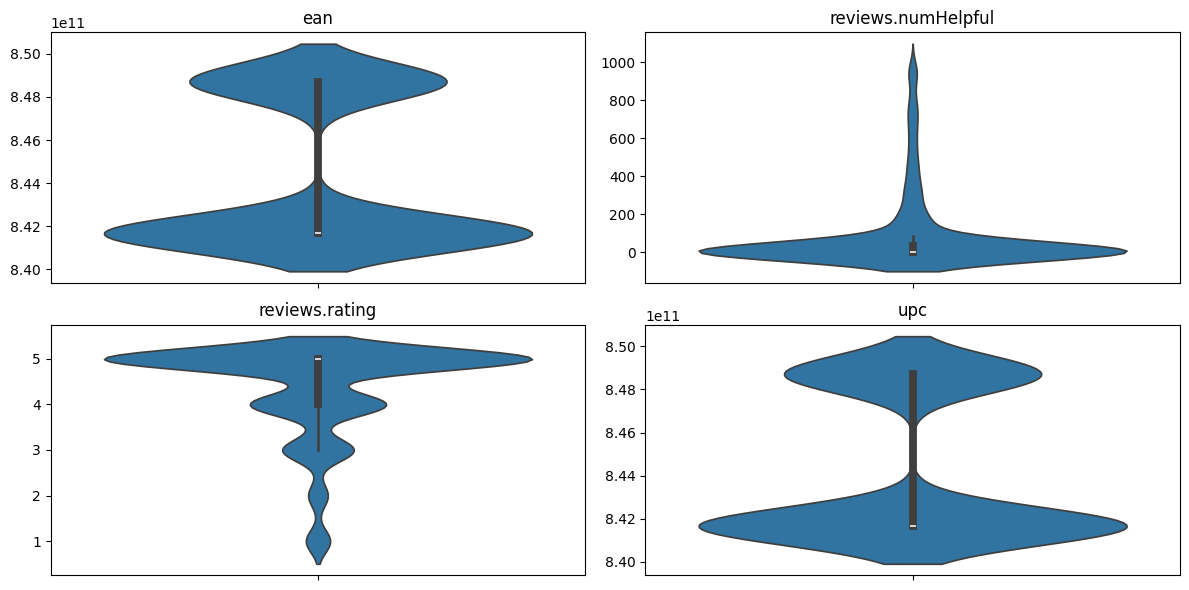

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.violinplot(data=df, y=col, ax=axes[i])

    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

HANDLING NULL VALUES

In [ ]:
df = df.dropna(subset=["reviews.rating"])

In [ ]:
df.isnull().sum()

,0
id,0
asins,0
brand,0
categories,0
colors,508
dateAdded,0
dateUpdated,0
dimension,620
ean,484
keys,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1177 entries, 0 to 1596
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1177 non-null   object 
 1   asins                1177 non-null   object 
 2   brand                1177 non-null   object 
 3   categories           1177 non-null   object 
 4   colors               669 non-null    object 
 5   dateAdded            1177 non-null   object 
 6   dateUpdated          1177 non-null   object 
 7   dimension            557 non-null    object 
 8   ean                  693 non-null    float64
 9   keys                 1177 non-null   object 
 10  manufacturer         726 non-null    object 
 11  manufacturerNumber   698 non-null    object 
 12  name                 1177 non-null   object 
 13  prices               1177 non-null   object 
 14  reviews.date         960 non-null    object 
 15  reviews.doRecommend  539 non-null    object

GETTING READ OF IRREVALENT COLUMNS

In [ ]:
print(df.columns.tolist())

['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'upc', 'weight']


FEATURE ENGINEERING

In [ ]:
df1=df[['reviews.text', 'reviews.rating']].copy()

In [ ]:
df1 = df1.reset_index(drop=True)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1177 entries, 0 to 1176
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviews.text    1177 non-null   object 
 1   reviews.rating  1177 non-null   float64
dtypes: float64(1), object(1)
memory usage: 18.5+ KB


In [ ]:
df1.columns = ['text', 'rating']

In [ ]:
print(df1['rating'].value_counts(normalize=True).sort_index() * 100)

rating
1.0     3.568394
2.0     2.888700
3.0    10.535259
4.0    20.050977
5.0    62.956669
Name: proportion, dtype: float64


Cleaning Data for NLP

In [ ]:
import re
import string

In [ ]:
def clean_text(text):
  text=str(text).lower()   #lowercase
  text = re.sub(r'<.*?>', ' ', text)  #html tags
  text = re.sub(r'http\S+|www\S+', ' ', text)  #urls
  text=text = re.sub(r'\d+', ' ', text)  #numbers
  text = text.translate(str.maketrans('', '', string.punctuation)) #punctuations
  text = re.sub(r'\s+', ' ', text).strip()  #extra space
  return text





In [ ]:
df1['clean_text'] = df1['text'].apply(clean_text)

In [ ]:
print("BEFORE:", df1['text'].iloc[0][:300])
print("\nAFTER :", df1['clean_text'].iloc[0][:300])

BEFORE: I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both model

AFTER : i initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing the paperwhite is great but if you have spending money go for the voyagefortunately i had friends who owned each so i ended up buying the paperwhite on this basis both models now h


TRAIN AND SPLIT DATA

In [ ]:
from sklearn.model_selection import train_test_split

X = df1['clean_text']
y = df1['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps class proportions the same in train and test
)

print("Train size:", len(X_train))
print("Test size: ", len(X_test))
print("\nTrain rating distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

Train size: 941
Test size:  236

Train rating distribution:
rating
1.0     3.613177
2.0     2.869288
3.0    10.520723
4.0    20.085016
5.0    62.911796
Name: proportion, dtype: float64


ADDING TF-IDF CLASSIFIER

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2),
    stop_words='english',
)

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
print("Vocab size:", len(vectorizer.vocabulary_))

Vocab size: 6228


LOGISTIC REGRESSION MODEL

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1,
)
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6610169491525424

Classification report:
              precision    recall  f1-score   support

         1.0      0.333     0.375     0.353         8
         2.0      0.200     0.143     0.167         7
         3.0      0.800     0.320     0.457        25
         4.0      0.411     0.489     0.447        47
         5.0      0.776     0.812     0.793       149

    accuracy                          0.661       236
   macro avg      0.504     0.428     0.443       236
weighted avg      0.673     0.661     0.655       236


Confusion matrix:
[[  3   0   0   2   3]
 [  1   1   1   1   3]
 [  1   4   8   6   6]
 [  1   0   0  23  23]
 [  3   0   1  24 121]]


LinearSVC model

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train
svc_model = LinearSVC(
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
)
svc_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svc = svc_model.predict(X_test_tfidf)

# Evaluate
print("=== LinearSVC ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("\nClassification report:")
print(classification_report(y_test, y_pred_svc, digits=3))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_svc))

=== LinearSVC ===
Accuracy: 0.690677966101695

Classification report:
              precision    recall  f1-score   support

         1.0      0.250     0.250     0.250         8
         2.0      0.250     0.143     0.182         7
         3.0      1.000     0.400     0.571        25
         4.0      0.500     0.426     0.460        47
         5.0      0.747     0.872     0.805       149

    accuracy                          0.691       236
   macro avg      0.549     0.418     0.454       236
weighted avg      0.693     0.691     0.674       236


Confusion matrix:
[[  2   1   0   1   4]
 [  1   1   0   1   4]
 [  1   2  10   2  10]
 [  1   0   0  20  26]
 [  3   0   0  16 130]]
